# Labeling the angular character of Yb 171

In [1]:
import logging

import matplotlib.pyplot as plt
import numpy as np

import rydstate

logging.getLogger("rydstate").setLevel(logging.ERROR)

In [2]:
skip_high_l = True
nu = 0, 130
l_r = 0
f_tot = 1 / 2

basis = rydstate.BasisMQDT("Yb171", nu, f_tot=f_tot, skip_high_l=skip_high_l)

In [3]:
print(f"Number of states in basis: {len(basis.states)}")
print("States in basis:")
for state in basis.states[:3]:
    print(state)
print("... ")

Number of states in basis: 781
States in basis:
0.9018467448458758*(RadialKet(nu=26.572676960033274, potential=PotentialFei2009Ytterbium171(l_r=0)), FJ(i_c=0.5, s_c=0.5, l_c=0, s_r=0.5, l_r=0, j_c=0.5, f_c=0.0, j_r=0.5, f_tot=0.5)), 0.0015259516475141963*(RadialKet(nu=1.8050464992879076, potential=PotentialDummy(l_r=Unknown)), FJ(i_c=0.5, s_c=0.5, l_c=Unknown, s_r=0.5, l_r=Unknown, j_c=Unknown, f_c=Unknown, j_r=Unknown, f_tot=0.5, label=4f13 5d 6snl a)), 0.0014774433765746442*(RadialKet(nu=1.8953308850400905, potential=PotentialFei2009Ytterbium171(l_r=1)), FJ(i_c=0.5, s_c=0.5, l_c=1, s_r=0.5, l_r=1, j_c=1.5, f_c=1.0, j_r=1.5, f_tot=0.5)), 0.000368177881042694*(RadialKet(nu=1.8050464992879076, potential=PotentialDummy(l_r=Unknown)), FJ(i_c=0.5, s_c=0.5, l_c=Unknown, s_r=0.5, l_r=Unknown, j_c=Unknown, f_c=Unknown, j_r=Unknown, f_tot=0.5, label=4f13 5d 6snl b)), 0.0008335399529702812*(RadialKet(nu=2.007943979247443, potential=PotentialFei2009Ytterbium171(l_r=1)), FJ(i_c=0.5, s_c=0.5, l_c=

In [4]:
basis.filter_states("j_tot", (0, float("inf")), keep_unknown=False)
basis.filter_states("f_c", (0, float("inf")), keep_unknown=False)
basis.filter_states("f_tot", f_tot)
basis.filter_states("l_r", l_r, delta=0.5)
basis.filter_states("l_c", 0, delta=0.3)

basis.sort_states("nu")

print(f"{basis.species} basis states: {len(basis)}")
print(f"  nu_min = {basis.states[0].nu}, nu_max = {basis.states[-1].nu}")

Yb171 basis states: 262
  nu_min = 2.501251480202191, nu_max = 129.68494203492332


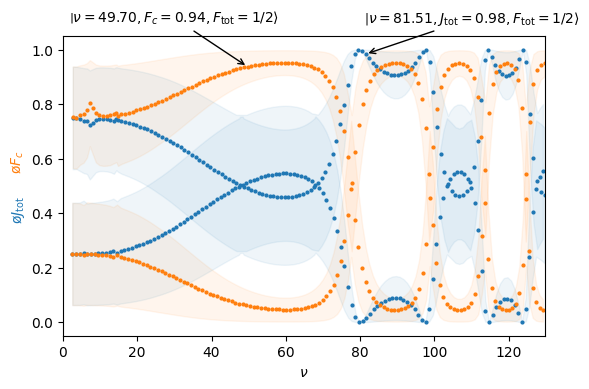

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))

qns_of_interest = ["j_tot", "f_c"]
legend_labels = {
    "f_tot": r"F_{\mathrm{tot}}",
    "s_tot": r"S_{\mathrm{tot}}",
    "l_tot": r"L_{\mathrm{tot}}",
    "j_tot": r"J_{\mathrm{tot}}",
    "j_r": r"j_{r}",
    "f_c": r"F_{c}",
    "i_c": r"I",
}

nu = basis.calc_exp_qn("nu")
for j, qn in enumerate(qns_of_interest):
    exp = basis.calc_exp_qn(qn)
    std = basis.calc_std_qn(qn) ** 2

    mean = np.mean(exp)
    for which in ["lower", "upper"]:
        idx = np.argwhere(exp < mean) if which == "lower" else np.argwhere(exp >= mean)

        exp_i = exp[idx].flatten()
        std_i = std[idx].flatten()
        nu_i = nu[idx].flatten()

        ax.plot(nu_i, exp_i, f"C{j}o", ms=2)
        ax.fill_between(nu_i, exp_i - std_i, exp_i + std_i, color=f"C{j}", alpha=0.07)


# labels
ax.set_xlabel(r"$\nu$")
ax.set_ylabel("")
for j, qn in enumerate(qns_of_interest):
    label = rf"$\mathrm{{\o}} {legend_labels[qn]}$"
    ax.text(-0.11, 0.5 + (2 * j - 1) * 0.08, label, transform=ax.transAxes, rotation=90, va="center", color=f"C{j}")

# lims
ax.set_xlim(0, nu[-1])


# annotations
kwargs = {"arrowprops": {"arrowstyle": "->", "facecolor": "black"}, "ha": "center"}


def get_label(state: rydstate.RydbergStateMQDT, qns: list[str]) -> str:
    label = rf"$\left|\nu={state.nu:.2f}"
    for qn in qns:
        exp_qn = state.angular.calc_exp_qn(qn)
        label += rf", {legend_labels[qn]}={exp_qn:.2f}"
    label += rf", {legend_labels['f_tot']}=1/2 \right\rangle$"
    return label


state = basis.states[97]
label = get_label(state, ["f_c"])
ax.annotate(label, xy=(state.nu, state.angular.calc_exp_qn("f_c")), xytext=(30, 1.1), **kwargs)

state = basis.states[161]
label = get_label(state, ["j_tot"])
ax.annotate(label, xy=(state.nu, state.angular.calc_exp_qn("j_tot")), xytext=(110, 1.1), **kwargs)

fig.tight_layout()
plt.show()